   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   

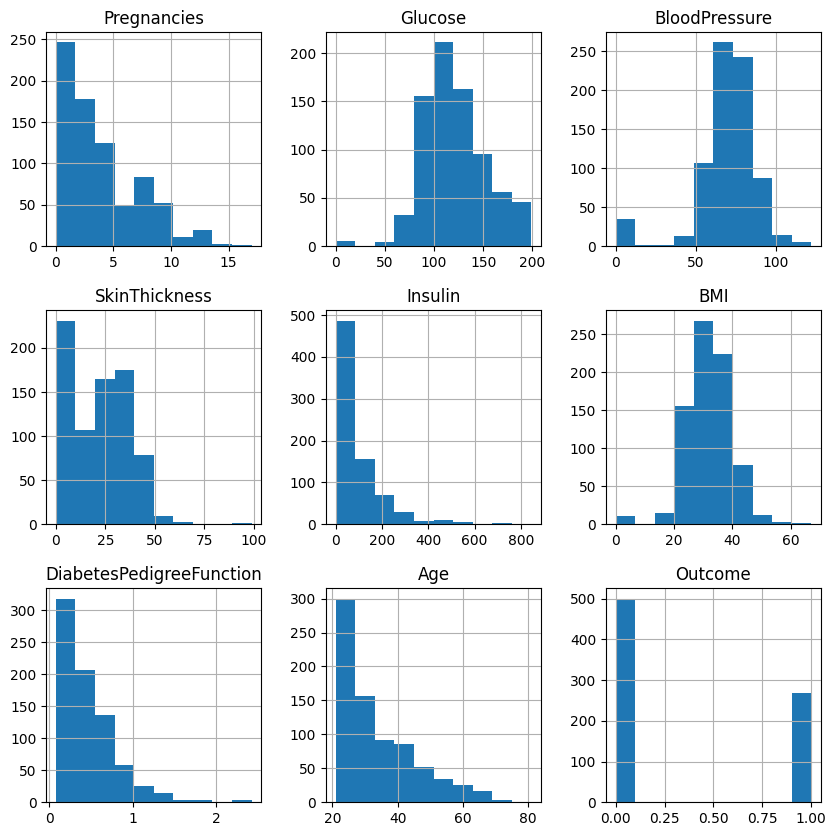

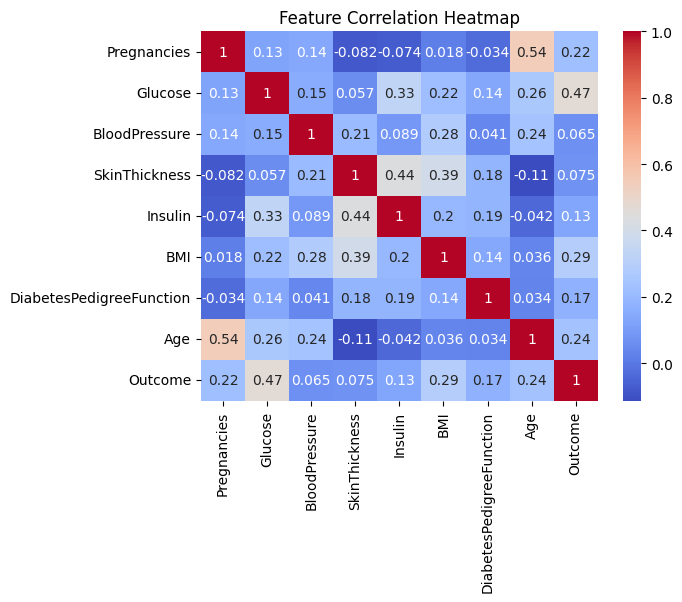

/tmp/ipython-input-2-1270348511.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Outcome', data=df, palette='Set1')


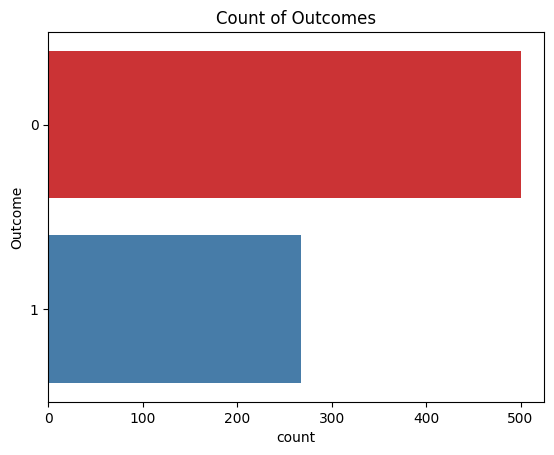

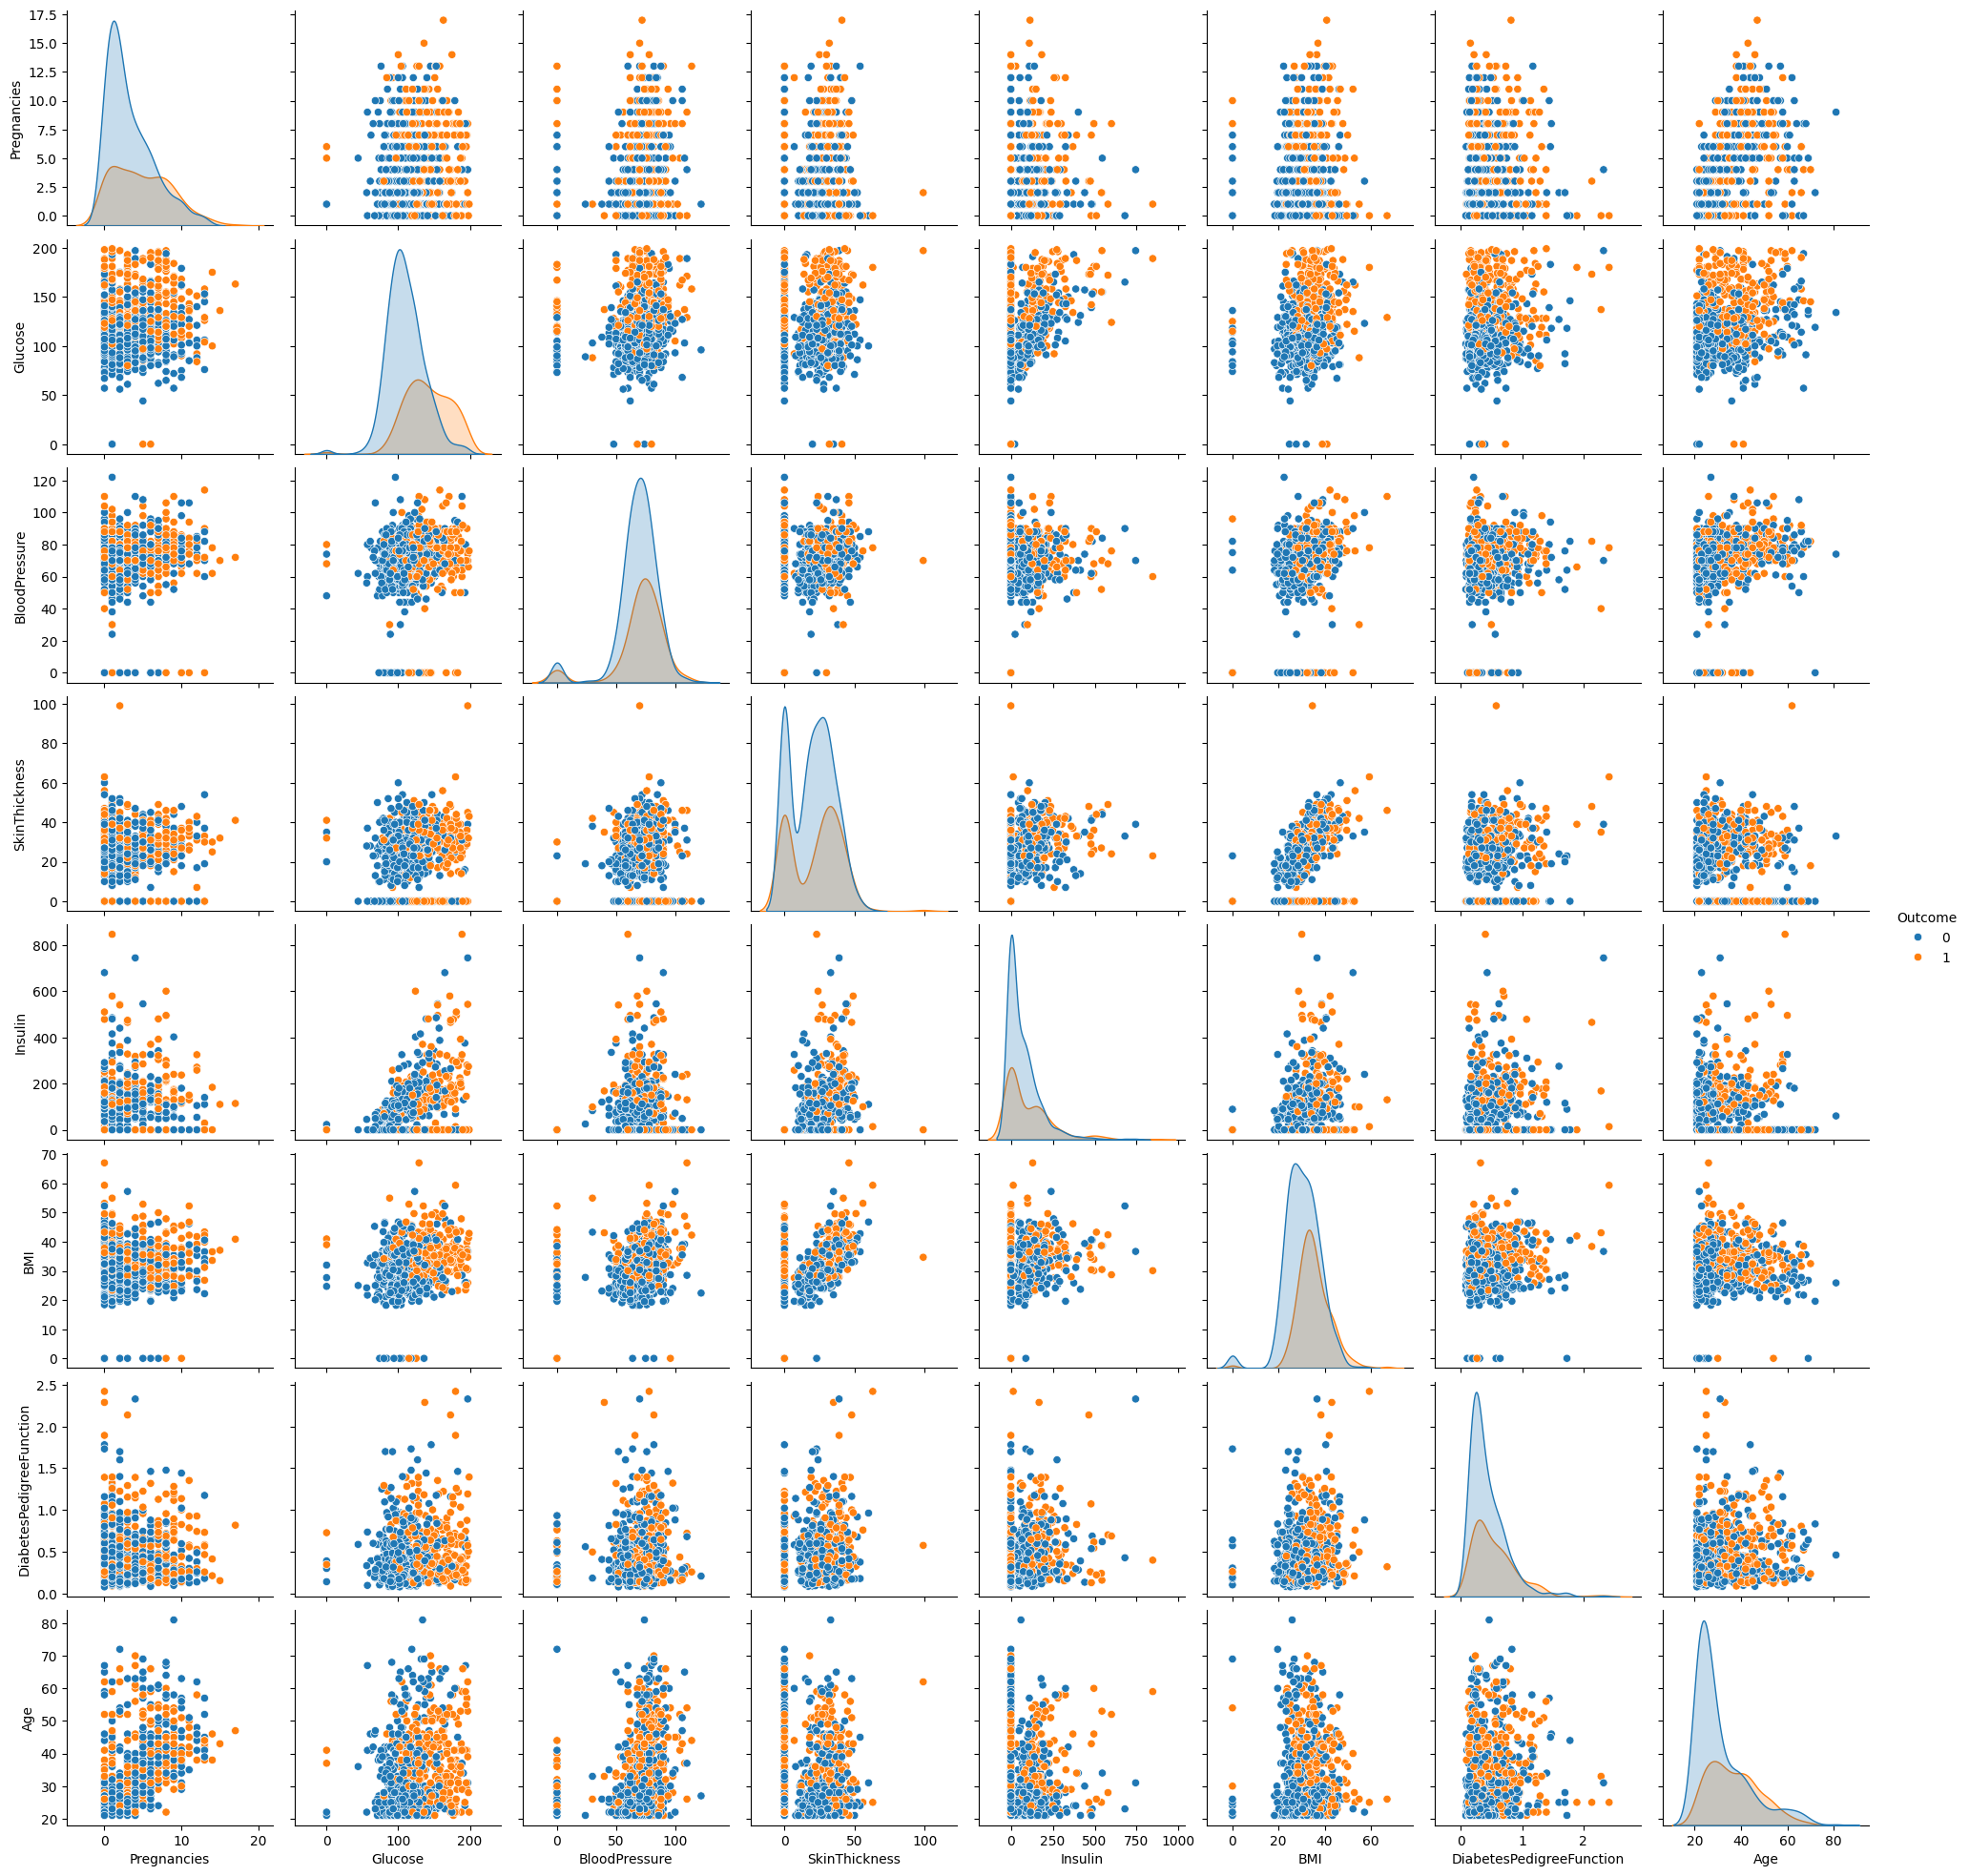

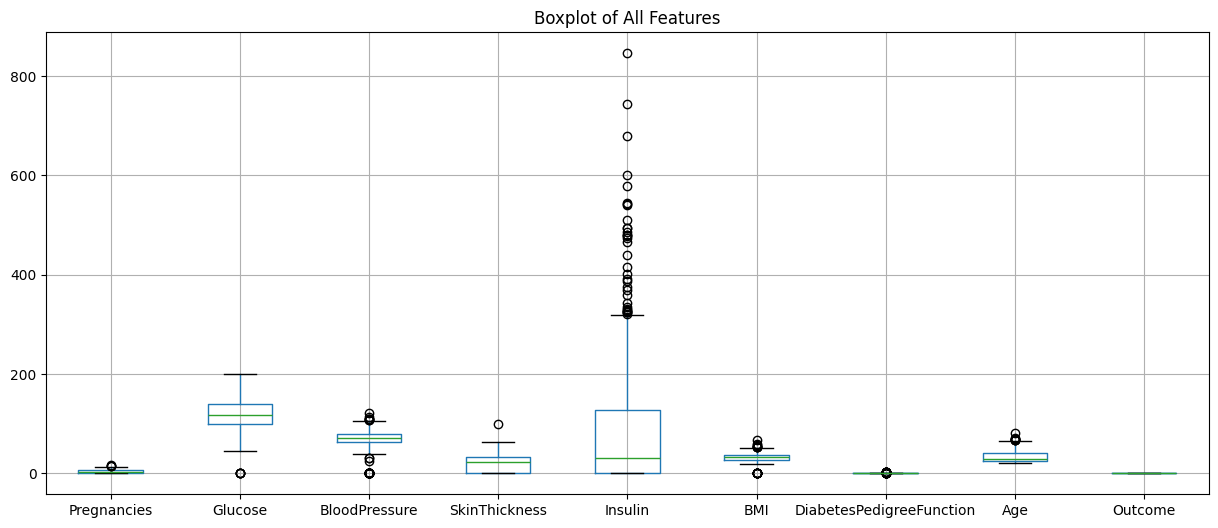

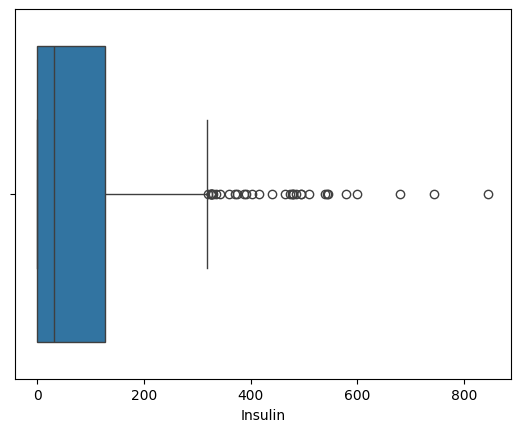

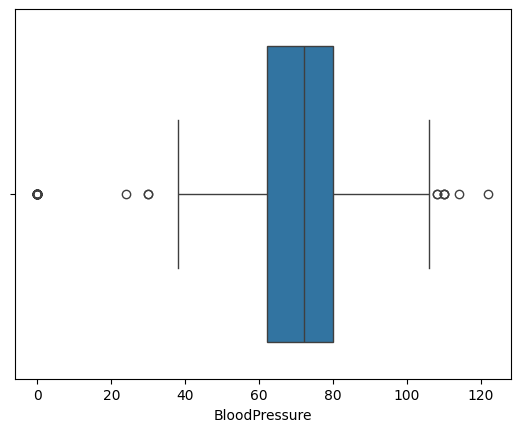

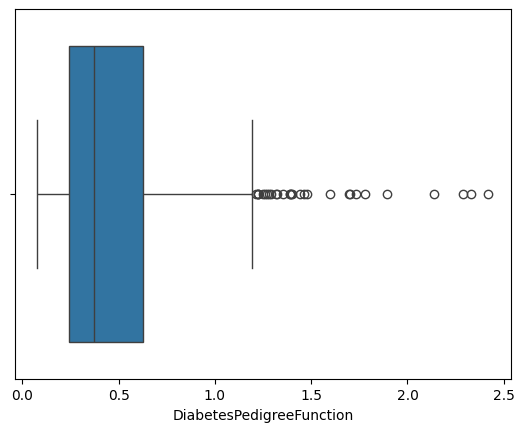

Original shape: (768, 9)
After outlier removal: (639, 9)


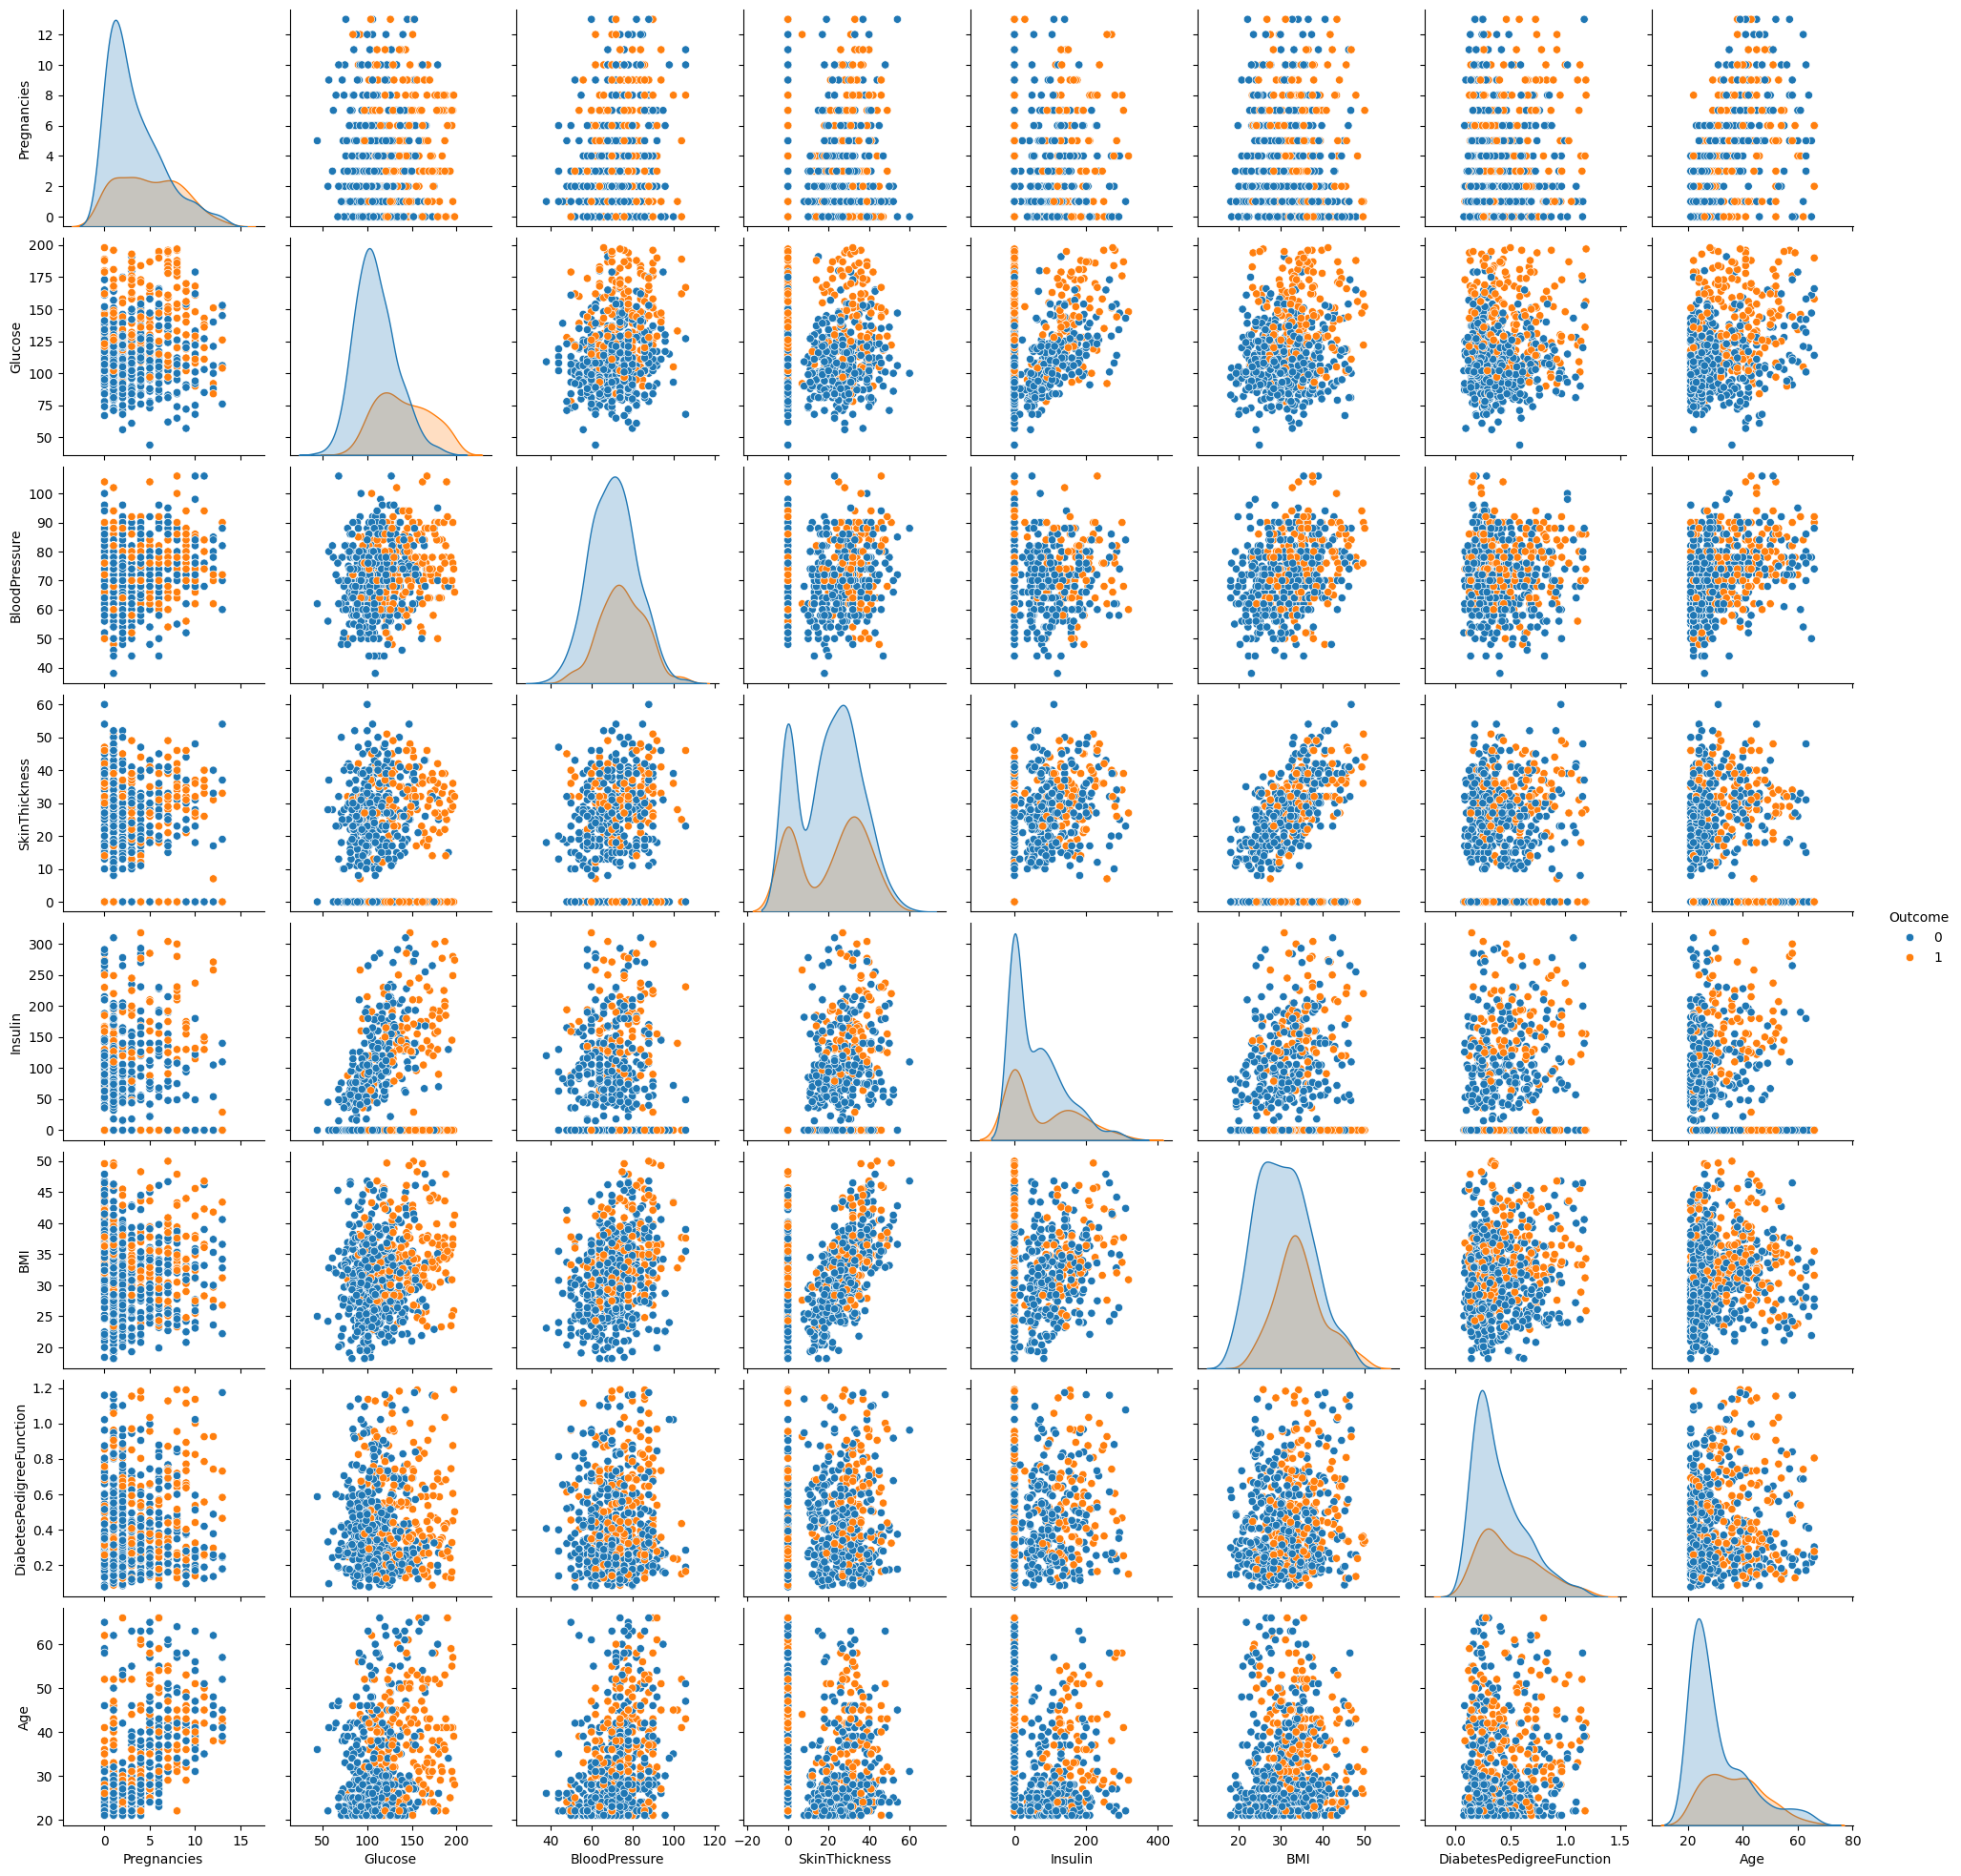

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


Logistic Regression:
TP: 8.6
TN: 30.8
FN: 7.8
FP: 3.9

Support Vector Machine:
TP: 8.4
TN: 31.3
FN: 8.0
FP: 3.4

K-Nearest Neighbors:
TP: 7.7
TN: 29.1
FN: 8.7
FP: 5.6

Random Forest:
TP: 8.4
TN: 30.8
FN: 8.0
FP: 3.9

Naive Bayes:
TP: 9.7
TN: 28.8
FN: 6.7
FP: 5.9

Gradient Boosting:
TP: 7.7
TN: 30.0
FN: 8.7
FP: 4.7


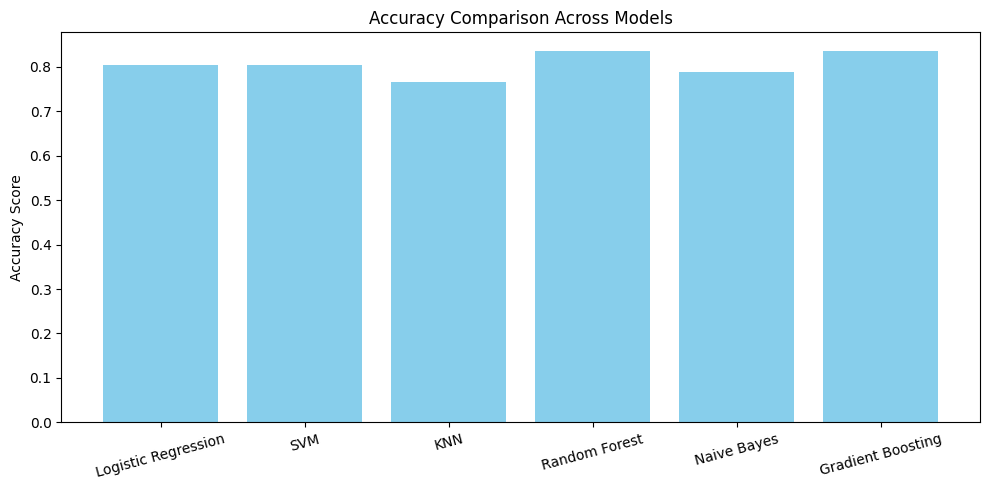

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load Data
df = pd.read_csv('/content/diabetes.csv')
print(df.head())
print(df.describe())
print(df.info())
print("Missing values present:", df.isnull().values.any())

# Data Visualization
df.hist(bins=10, figsize=(10, 10))
plt.show()

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

sns.countplot(y='Outcome', data=df, palette='Set1')
plt.title('Count of Outcomes')
plt.show()

sns.pairplot(df, hue="Outcome")
plt.show()

df.boxplot(figsize=(15, 6))
plt.title("Boxplot of All Features")
plt.show()

# Individual Feature Boxplots
sns.boxplot(x='Insulin', data=df)
plt.show()

sns.boxplot(x='BloodPressure', data=df)
plt.show()

sns.boxplot(x='DiabetesPedigreeFunction', data=df)
plt.show()

# Outlier Removal using IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_out = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
print("Original shape:", df.shape)
print("After outlier removal:", df_out.shape)

sns.pairplot(df_out, hue="Outcome")
plt.show()

# Splitting Features and Target
X = df_out.drop(columns=['Outcome'])
y = df_out['Outcome']

from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

# Metrics
from sklearn.metrics import confusion_matrix, accuracy_score, make_scorer, roc_auc_score
from sklearn.model_selection import cross_validate

def tn(y_true, y_pred): return confusion_matrix(y_true, y_pred)[0, 0]
def fp(y_true, y_pred): return confusion_matrix(y_true, y_pred)[0, 1]
def fn(y_true, y_pred): return confusion_matrix(y_true, y_pred)[1, 0]
def tp(y_true, y_pred): return confusion_matrix(y_true, y_pred)[1, 1]

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'tp': make_scorer(tp),
    'tn': make_scorer(tn),
    'fp': make_scorer(fp),
    'fn': make_scorer(fn)
}

def display_result(result):
    print("TP:", result['test_tp'].mean())
    print("TN:", result['test_tn'].mean())
    print("FN:", result['test_fn'].mean())
    print("FP:", result['test_fp'].mean())

# Model Training and Evaluation
acc = []
roc = []
models = []
names = []

from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(train_X, train_y)
y_pred = clf.predict(test_X)
acc.append(accuracy_score(test_y, y_pred))
roc.append(roc_auc_score(test_y, y_pred))
names.append("Logistic Regression")
result = cross_validate(clf, train_X, train_y, scoring=scoring, cv=10)
print("\nLogistic Regression:")
display_result(result)

from sklearn.svm import SVC
clf = SVC(kernel='linear', probability=True)
clf.fit(train_X, train_y)
y_pred = clf.predict(test_X)
acc.append(accuracy_score(test_y, y_pred))
roc.append(roc_auc_score(test_y, y_pred))
names.append("SVM")
result = cross_validate(clf, train_X, train_y, scoring=scoring, cv=10)
print("\nSupport Vector Machine:")
display_result(result)

from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(train_X, train_y)
y_pred = clf.predict(test_X)
acc.append(accuracy_score(test_y, y_pred))
roc.append(roc_auc_score(test_y, y_pred))
names.append("KNN")
result = cross_validate(clf, train_X, train_y, scoring=scoring, cv=10)
print("\nK-Nearest Neighbors:")
display_result(result)

from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()
clf.fit(train_X, train_y)
y_pred = clf.predict(test_X)
acc.append(accuracy_score(test_y, y_pred))
roc.append(roc_auc_score(test_y, y_pred))
names.append("Random Forest")
result = cross_validate(clf, train_X, train_y, scoring=scoring, cv=10)
print("\nRandom Forest:")
display_result(result)

from sklearn.naive_bayes import GaussianNB
clf = GaussianNB()
clf.fit(train_X, train_y)
y_pred = clf.predict(test_X)
acc.append(accuracy_score(test_y, y_pred))
roc.append(roc_auc_score(test_y, y_pred))
names.append("Naive Bayes")
result = cross_validate(clf, train_X, train_y, scoring=scoring, cv=10)
print("\nNaive Bayes:")
display_result(result)

from sklearn.ensemble import GradientBoostingClassifier
clf = GradientBoostingClassifier(n_estimators=50, learning_rate=0.2)
clf.fit(train_X, train_y)
y_pred = clf.predict(test_X)
acc.append(accuracy_score(test_y, y_pred))
roc.append(roc_auc_score(test_y, y_pred))
names.append("Gradient Boosting")
result = cross_validate(clf, train_X, train_y, scoring=scoring, cv=10)
print("\nGradient Boosting:")
display_result(result)

# Accuracy Comparison Plot
plt.figure(figsize=(10, 5))
plt.bar(names, acc, color='skyblue')
plt.title("Accuracy Comparison Across Models")
plt.ylabel("Accuracy Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()